
# Customer Segmentation Model (Financial Health × Engagement)
### ITB Consumer Finance — Vietnam 2025 synthetic case study


## 1. Setup & reproducibility

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Environment ready. Seed =", SEED)


Environment ready. Seed = 42


## 2. Load data

In [2]:
import os
import pandas as pd
from google.colab import drive

# 1. Kết nối Google Drive vào Colab
drive.mount("/content/drive")

# 2. Khai báo danh sách các đường dẫn khả thi trong Colab Notebooks
CANDIDATE_DIRS = [
    "/content/drive/MyDrive/Colab Notebooks",
    "/content/drive/MyDrive/Colab Notebooks/datasets",
    "/content/drive/MyDrive",
    "/content",
]


def find_file(name):
    for d in CANDIDATE_DIRS:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Khong tim thay {name} trong Google Drive.")


# 3. Tìm và tải file
ENGAGEMENT_PATH = find_file("consumer_financial_health_engagement_2025.csv")
print("Loading:", ENGAGEMENT_PATH)

df = pd.read_csv(ENGAGEMENT_PATH)
print("Shape:", df.shape)
display(df.head(3))

Mounted at /content/drive
Loading: /content/consumer_financial_health_engagement_2025.csv
Shape: (10992, 30)


,consumer_id,analysis_month,age,gender,occupation,province_city,monthly_income_vnd,credit_limit_vnd,opening_balance_vnd,ending_balance_vnd,total_spend_vnd,essential_spend_vnd,discretionary_spend_vnd,online_spend_vnd,transaction_count,active_transaction_days,average_transaction_value_vnd,category_diversity,essential_spend_ratio,discretionary_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,transaction_recency_days,spending_volatility,engagement_score,financial_health_score,engagement_segment,financial_health_segment,next_month_low_health_flag
0,KH00100010,2025-01-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,1003930000,3780600000,501965000,1065133000,440762000,138355000,302407000,69095000,169,31,2608059,14,0.313900,0.686100,0.156763,0.4390,0.1166,0,0.978194,77.4,74.4,Tương tác cao,Ổn định,0.0
1,KH00100010,2025-02-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,961510000,3780600000,1065133000,1627173000,399470000,150487000,248983000,58800000,182,28,2194890,14,0.376717,0.623283,0.147195,0.4155,0.1057,0,0.891546,77.1,76.3,Tương tác cao,Ổn định,0.0
2,KH00100010,2025-03-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,916740000,3780600000,1627173000,2029964000,513949000,180684000,333265000,95894000,212,30,2424288,14,0.351560,0.648440,0.186583,0.5606,0.1359,0,0.972394,79.0,71.2,Tương tác cao,Ổn định,0.0




```
# This is formatted as code
```


## 3. Kiểm tra dữ liệu




### 3.1. Tìm điểm bất thường

In [3]:
def audit_dataset_anomalies(df: pd.DataFrame):
    print("BÁO CÁO KIỂM TRA DỮ LIỆU BẤT THƯỜNG")

    # 1. Phát hiện Unbalanced History (Số tháng giao dịch / consumer_id)
    month_counts = df.groupby("consumer_id")["analysis_month"].nunique()
    short_history_custs = month_counts[month_counts < 12]

    print("\n1. BẤT THƯỜNG VỀ THỜI GIAN HOẠT ĐỘNG (TENURE):")
    print(f"- Tổng số khách hàng duy nhất : {len(month_counts):,} KH")
    print(
        f"- Số tháng dữ liệu tối đa      : {month_counts.max()} tháng (Phù hợp chuẩn)"
    )
    print(
        f"- PHÁT HIỆN KHÁCH THIẾU DỮ LIỆU: {len(short_history_custs):,} KH (< 12 tháng history)"
    )

    print("\n   Phân bổ số tháng hoạt động chi tiết:")
    for m, count in month_counts.value_counts().sort_index().items():
        pct = (count / len(month_counts)) * 100
        status = "[BẤT THƯỜNG]" if m < 12 else " [ĐỦ ĐIỀU KIỆN]"
        print(f"   + Có {m} tháng dữ liệu : {count:3d} KH ({pct:5.1f}%) {status}")

    # 2. Phát hiện giá trị NaN / Inf do chia cho 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    inf_counts = np.isinf(df[numeric_cols]).sum()
    nan_counts = df[numeric_cols].isna().sum()

    print("\n2. BẤT THƯỜNG VỀ GIÁ TRỊ LỖI (NaN / Inf):")
    inf_cols = inf_counts[inf_counts > 0]
    nan_cols = nan_counts[nan_counts > 0]

    if len(inf_cols) == 0 and len(nan_cols) == 0:
        print("Không phát hiện lỗi NaN hoặc Vô cực (Inf) ở cấp độ dòng.")
    else:
        for col, cnt in inf_cols.items():
            print(f"Cột '{col}' chứa {cnt} giá trị Vô cực (Inf)")
        for col, cnt in nan_cols.items():
            print(f"Cột '{col}' chứa {cnt} giá trị Khuyết (NaN)")

    # 3. Phát hiện lỗi biến động chi tiêu (Spending Volatility) = NaN hoặc 0
    # Tính thử stddev chi tiêu theo từng khách
    cust_std = df.groupby("consumer_id")["spend_to_income_ratio"].std()
    zero_vol = cust_std[cust_std == 0]
    nan_vol = cust_std[cust_std.isna()]

    print("\n3. BẤT THƯỜNG VỀ ĐỘ BIẾN ĐỘNG (VOLATILITY):")
    print(
        f"    {len(nan_vol)} KH có Std Dev = NaN (Do chỉ có đúng 1 tháng dữ liệu, không tính được độ lệch chuẩn)"
    )
    print(
        f"    {len(zero_vol)} KH có Std Dev = 0.0 (Chi tiêu hoàn toàn không đổi qua các tháng)"
    )

    return short_history_custs.index.tolist()


# CHẠY TÌM BẤT THƯỜNG
bad_customer_ids = audit_dataset_anomalies(df)

BÁO CÁO KIỂM TRA DỮ LIỆU BẤT THƯỜNG

1. BẤT THƯỜNG VỀ THỜI GIAN HOẠT ĐỘNG (TENURE):
- Tổng số khách hàng duy nhất : 999 KH
- Số tháng dữ liệu tối đa      : 12 tháng (Phù hợp chuẩn)
- PHÁT HIỆN KHÁCH THIẾU DỮ LIỆU: 91 KH (< 12 tháng history)

   Phân bổ số tháng hoạt động chi tiết:
   + Có 1 tháng dữ liệu :  86 KH (  8.6%) [BẤT THƯỜNG]
   + Có 2 tháng dữ liệu :   5 KH (  0.5%) [BẤT THƯỜNG]
   + Có 12 tháng dữ liệu : 908 KH ( 90.9%)  [ĐỦ ĐIỀU KIỆN]

2. BẤT THƯỜNG VỀ GIÁ TRỊ LỖI (NaN / Inf):
Cột 'next_month_low_health_flag' chứa 999 giá trị Khuyết (NaN)

3. BẤT THƯỜNG VỀ ĐỘ BIẾN ĐỘNG (VOLATILITY):
    86 KH có Std Dev = NaN (Do chỉ có đúng 1 tháng dữ liệu, không tính được độ lệch chuẩn)
    0 KH có Std Dev = 0.0 (Chi tiêu hoàn toàn không đổi qua các tháng)


## 3.2. Data quality check
Kiểm tra nhanh trước khi build feature — đảm bảo mỗi `consumer_id` có nhiều dòng (nhiều tháng), không trùng lặp (consumer_id, analysis_month), và các cột tỷ lệ nằm trong khoảng hợp lệ theo data dictionary.

In [4]:
n_consumers = df["consumer_id"].nunique()
n_rows = len(df)
dup_key = df.duplicated(subset=["consumer_id", "analysis_month"]).sum()

print(f"Số dòng (consumer-month): {n_rows:,}")
print(f"Số khách hàng duy nhất : {n_consumers:,}")
print(f"Số tháng trung bình/KH : {n_rows / n_consumers:.2f}")
print(f"Dòng trùng (consumer_id, analysis_month): {dup_key}")

# next_month_low_health_flag: NaN o thang 12 la HOP LE (khong co label thang ke tiep)
na_counts = df.isna().sum()
print("\nCác cột có giá trị thiếu:")
print(na_counts[na_counts > 0])

ratio_cols = ["essential_spend_ratio", "discretionary_spend_ratio", "online_spend_ratio"]
for c in ratio_cols:
    lo, hi = df[c].min(), df[c].max()
    print(f"{c}: min={lo:.3f}  max={hi:.3f}  (expected 0-1)")

Số dòng (consumer-month): 10,992
Số khách hàng duy nhất : 999
Số tháng trung bình/KH : 11.00
Dòng trùng (consumer_id, analysis_month): 0

Các cột có giá trị thiếu:
next_month_low_health_flag    999
dtype: int64
essential_spend_ratio: min=0.000  max=1.000  (expected 0-1)
discretionary_spend_ratio: min=0.000  max=1.000  (expected 0-1)
online_spend_ratio: min=0.000  max=0.996  (expected 0-1)


## 3.3. Kiểm tra nhân khẩu học & tính nhất quán tỷ lệ chi tiêu

Có hai nhóm cần kiểm tra

1. **Tính hợp lệ của các trường nhân khẩu học** (`age`, `gender`, `province_city`, `occupation`)
2. **Tính nhất quán nội tại**: `essential_spend_ratio + discretionary_spend_ratio` phải bằng đúng 1,
   vì đây là hai phần bù của cùng một phép chia.

In [5]:
# Kiểm tra nhân khẩu học
print("Số tỉnh/thành duy nhất:", df["province_city"].nunique(), "(kỳ vọng: 34)")
print("Giá trị giới tính:", df["gender"].unique().tolist())
print(f"Khoảng tuổi: {df['age'].min()} - {df['age'].max()} (kỳ vọng: 14-96)")
print("Số dòng thiếu occupation:", df["occupation"].isna().sum())

# Kiểm tra tính nhất quán essential + discretionary = 1
ratio_sum_diff = (df["essential_spend_ratio"] + df["discretionary_spend_ratio"] - 1).abs()
print(f"\nChênh lệch tối đa so với 1 (essential + discretionary): {ratio_sum_diff.max():.6f}")
print(f"Tương quan giữa 2 cột: {df['essential_spend_ratio'].corr(df['discretionary_spend_ratio']):.3f}")

Số tỉnh/thành duy nhất: 34 (kỳ vọng: 34)
Giá trị giới tính: ['Nam', 'Nữ']
Khoảng tuổi: 15 - 96 (kỳ vọng: 14-96)
Số dòng thiếu occupation: 0

Chênh lệch tối đa so với 1 (essential + discretionary): 0.000000
Tương quan giữa 2 cột: -1.000



## 4. Feature engineering

| Feature | Ý nghĩa |
|---|---|
| `financial_health_score` | Trục sức khoẻ tài chính (0–100) |
| `engagement_score` | Trục mức độ tương tác (0–100) |
| `essential_spend_ratio` | Tỷ trọng chi tiêu thiết yếu |
| `online_spend_ratio` | Mức độ dùng kênh số |
| `spend_to_income_ratio` | Áp lực chi tiêu so với thu nhập |
| `credit_utilization_ratio` | Mức độ sử dụng hạn mức tín dụng |
| `category_diversity` | Đa dạng ngành hàng sử dụng |
| `transaction_recency_days` | Độ "mới" của giao dịch gần nhất |
| `spending_volatility` | Biến động chi tiêu (hệ số biến thiên) |


Ta sẽ chia dữ liệu thành hai nhóm riêng lẻ:
+ Nhóm đầu tiên là dữ liệu phân cụm: Ta sẽ sử dụng chính chỉ số thể hiện cách khách hàng dùng tiền để tìm ra các nhóm người có thói quen giống nhau

+ Nhóm thứ hai là dữ liệu thuộc tính (Giả sử sau khi chạy K means, máy tính ra kq cụm 1.Lúc này, bảng profile mới được kích hoạt và ghép vào để tổng hợp thông tin)

Các column bị loại:
+ monthly_income_vnd và credit_limit_vnd. Theo yêu cầu đề bài, dữ liệu tiền VND giả lập bị phóng đại không thực tế -> dẫn đến việc phân loại bị nhầm lẫn

+ Loại bỏ transactions_count và active transactions_days vì engagement_score vốn dĩ được hệ thống tính toán sẵn dựa trên số giao dịch và số ngày hoạt động

+ Loại bỏ dictionary_spend_ratio vì bản chất đã có sẵn chi tiêu thiết yếu và không thiết yếu. Nếu như điền cả hai vào sẽ bị duplicate

### 4.1. Tách dữ liệu thành hai luồng xử lý

In [6]:
# TÁCH DỮ LIỆU — chuyển lên đầu tiên vì các bước sau đều phụ thuộc df_valid/df_short
months_per_cust = df.groupby("consumer_id")["analysis_month"].nunique()

valid_ids = months_per_cust[months_per_cust >= 12].index
short_ids = months_per_cust[months_per_cust < 12].index

df_valid = df[df["consumer_id"].isin(valid_ids)].copy()
df_short = df[df["consumer_id"].isin(short_ids)].copy()

print(f"Đã phân tách: {len(valid_ids)} KH chuẩn | {len(short_ids)} KH mới/ngắn hạn")

Đã phân tách: 908 KH chuẩn | 91 KH mới/ngắn hạn


In [7]:
feature_cols = [
    "financial_health_score", "engagement_score",
    "essential_spend_ratio", "online_spend_ratio",
    "spend_to_income_ratio", "credit_utilization_ratio",
    "category_diversity", "transaction_recency_days",
    "spending_volatility",
]

cust = df_valid.groupby("consumer_id")[feature_cols].mean().reset_index() # Chỉ dùng df_valid (908 KH)
print("Customer-level profile shape (df_valid only):", cust.shape)
cust[feature_cols].describe().T[["mean", "std", "min", "max"]].round(3)

Customer-level profile shape (df_valid only): (908, 10)


,mean,std,min,max
financial_health_score,66.373,4.416,42.317,80.825
engagement_score,78.079,3.061,69.792,84.317
essential_spend_ratio,0.484,0.063,0.245,0.640
online_spend_ratio,0.206,0.034,0.122,0.360
spend_to_income_ratio,0.700,0.149,0.301,1.177
credit_utilization_ratio,0.192,0.057,0.062,0.429
category_diversity,13.739,0.339,12.500,14.000
transaction_recency_days,0.051,0.095,0.000,0.583
spending_volatility,1.571,0.415,0.761,3.605


### 4.2. Kiểm chứng correlation

In [8]:
"""### 4.2. Kiểm chứng correlation"""

corr_cols = ["engagement_score", "transaction_count", "active_transaction_days"]
corr_matrix = df[corr_cols].corr()

print("MA TRẬN TƯƠNG QUAN KIỂM CHỨNG BỘ TIỀN ĐỀU VÀO")
print(corr_matrix.round(3))
print("\n-> Kết quả:")
print(f"- Corr(engagement_score, transaction_count): {corr_matrix.loc['engagement_score', 'transaction_count']:.3f}")
print(f"- Corr(engagement_score, active_transaction_days): {corr_matrix.loc['engagement_score', 'active_transaction_days']:.3f}")

feature_cols = [
    "financial_health_score", "engagement_score",
    "essential_spend_ratio", "online_spend_ratio",
    "spend_to_income_ratio", "credit_utilization_ratio",
    "category_diversity", "transaction_recency_days",
    "spending_volatility",
]

MA TRẬN TƯƠNG QUAN KIỂM CHỨNG BỘ TIỀN ĐỀU VÀO
                         engagement_score  transaction_count  active_transaction_days
engagement_score                    1.000              0.404                    0.589
transaction_count                   0.404              1.000                    0.546
active_transaction_days             0.589              0.546                    1.000

-> Kết quả:
- Corr(engagement_score, transaction_count): 0.404
- Corr(engagement_score, active_transaction_days): 0.589


### 4.3. Tổng hợp dữ liệu khách hàng

In [9]:
"""### 4.3. Tổng hợp dữ liệu khách hàng"""

cluster_cols = feature_cols  # 9 biến clustering, giữ tên cũ để không phải sửa các bước dưới

# 1. Bảng Clustering (9 chỉ số) - từ 908 khách hàng Full History
cust_cluster = (
    df_valid.groupby("consumer_id")[cluster_cols].mean().reset_index()
)
cust_cluster[cluster_cols] = cust_cluster[cluster_cols].replace([np.inf, -np.inf], np.nan)
cust_cluster[cluster_cols] = cust_cluster[cluster_cols].fillna(cust_cluster[cluster_cols].median())

# 2. Bảng Profiling (giữ nguyên VND & nhân khẩu học)
cat_cols = [c for c in ["age", "gender", "occupation", "province_city",
                          "financial_health_segment", "engagement_segment"] if c in df.columns]
num_cols = [c for c in ["monthly_income_vnd", "credit_limit_vnd",
                          "average_transaction_value_vnd", "transaction_count",
                          "active_transaction_days"] if c in df.columns]

cust_profile = pd.concat(
    [df_valid.groupby("consumer_id")[cat_cols].first(),
     df_valid.groupby("consumer_id")[num_cols].mean()],
    axis=1,
).reset_index()

print("Đã tạo xong cust_cluster và cust_profile cho", len(valid_ids), "khách hàng Full History")

Đã tạo xong cust_cluster và cust_profile cho 908 khách hàng Full History


## 5. Kiểm tra outlier (IQR) & Standardize bằng RobustScaler

In [10]:
iqr_report = []
bounds = {}
for col in cluster_cols:
    q1, q3 = cust_cluster[col].quantile(0.25), cust_cluster[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    bounds[col] = (lower, upper)
    n_out = ((cust_cluster[col] < lower) | (cust_cluster[col] > upper)).sum()
    iqr_report.append({"feature": col, "lower_bound": lower, "upper_bound": upper,
                        "n_outliers": n_out, "pct_outliers": round(n_out / len(cust_cluster) * 100, 2)})
iqr_df = pd.DataFrame(iqr_report)
print("BÁO CÁO OUTLIER THEO IQR")
print(iqr_df.round(3))

X_capped = cust_cluster[cluster_cols].copy()
for col in cluster_cols:
    lower, upper = bounds[col]
    X_capped[col] = X_capped[col].clip(lower=lower, upper=upper)

assert X_capped.shape[0] == len(valid_ids)
assert X_capped.isna().sum().sum() == 0
assert np.isfinite(X_capped.to_numpy()).all()

scaler = RobustScaler()
Xs = scaler.fit_transform(X_capped)
print("Scaled feature matrix (RobustScaler theo IQR):", Xs.shape)

BÁO CÁO OUTLIER THEO IQR
                    feature  lower_bound  upper_bound  n_outliers  pct_outliers
0    financial_health_score       55.007       77.649          13          1.43
1          engagement_score       70.444       85.927           3          0.33
2     essential_spend_ratio        0.337        0.644          24          2.64
3        online_spend_ratio        0.119        0.293          10          1.10
4     spend_to_income_ratio        0.277        1.117           6          0.66
5  credit_utilization_ratio        0.030        0.347           9          0.99
6        category_diversity       12.958       14.625          28          3.08
7  transaction_recency_days       -0.125        0.208          76          8.37
8       spending_volatility        0.598        2.523          22          2.42
Scaled feature matrix (RobustScaler theo IQR): (908, 9)



## 6. Chọn số cụm K — Elbow method + Silhouette Score

- **Elbow (inertia):** tìm điểm "khuỷu tay" nơi thêm cụm không còn giảm nhiều inertia.
- **Silhouette Score** (−1 đến 1, càng cao càng tốt): đo mức độ 1 điểm dữ liệu gần cụm của nó hơn so với cụm khác.
- **Davies–Bouldin Index** (càng thấp càng tốt): đo mức độ chồng lấn giữa các cụm.



BẢNG ĐÁNH GIÁ CHỈ SỐ K-MEANS (sau IQR + RobustScaler)
   k    inertia  silhouette  davies_bouldin  smallest_cluster_pct
0  2  3608.2949      0.3017          1.4514               25.5507
1  3  2994.9063      0.2133          1.5643               22.3568
2  4  2598.7015      0.2189          1.3865               19.1630
3  5  2397.7924      0.1954          1.3360               12.7753
4  6  2212.4594      0.1899          1.4935               10.4626
5  7  2041.6017      0.2123          1.4312                8.1498
6  8  1908.0908      0.2015          1.4243                7.7093


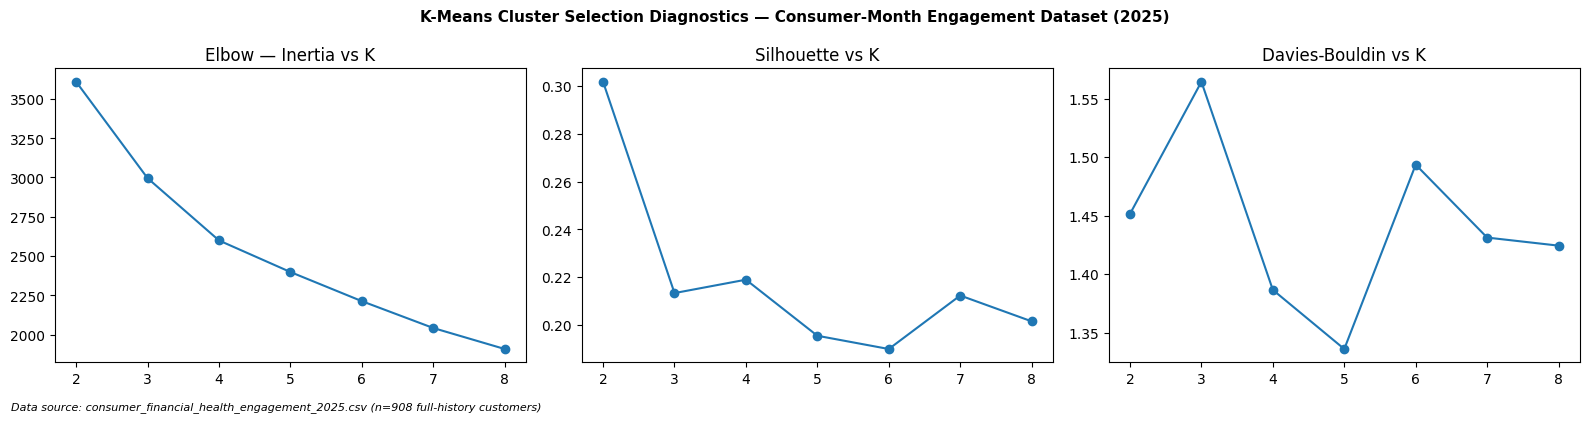

In [11]:
k_range = range(2, 9)
rows = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(Xs)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Xs, labels),
                 "davies_bouldin": davies_bouldin_score(Xs, labels),
                 "smallest_cluster_pct": pd.Series(labels).value_counts(normalize=True).min() * 100})
k_eval = pd.DataFrame(rows)
print("BẢNG ĐÁNH GIÁ CHỈ SỐ K-MEANS (sau IQR + RobustScaler)")
print(k_eval.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(k_eval["k"], k_eval["inertia"], marker="o"); axes[0].set_title("Elbow — Inertia vs K")
axes[1].plot(k_eval["k"], k_eval["silhouette"], marker="o"); axes[1].set_title("Silhouette vs K")
axes[2].plot(k_eval["k"], k_eval["davies_bouldin"], marker="o"); axes[2].set_title("Davies-Bouldin vs K")
fig.suptitle("K-Means Cluster Selection Diagnostics — Consumer-Month Engagement Dataset (2025)", fontsize=11, fontweight="bold")
fig.text(0.01, -0.02, "Data source: consumer_financial_health_engagement_2025.csv (n=908 full-history customers)", fontsize=8, style="italic")
plt.tight_layout()
plt.savefig("k_selection.png", dpi=110)
plt.show()


Inertia (Độ biến động nội bộ) — "Khách hàng trong cùng một nhóm có giống nhau không?"
Mục đích: Đo tổng mức độ "sai lệch" của các khách hàng so với trung bình của nhóm đó. Chỉ số này càng nhỏ tức là khách hàng trong nhóm càng giống nhau. Giống như việc gom khách hàng vào từng gian hàng. Gian hàng càng được sắp xếp ngăn nắp (Inertia nhỏ), bạn càng dễ đưa ra đúng một loại sản phẩm phù hợp cho toàn bộ người trong gian hàng đó. Tuy nhiên, nếu chia quá nhiều gian hàng thì chi phí quản lý sẽ tăng vọt. Vì vậy, ta tìm điểm "khuỷu tay" — nơi việc chia thêm gian hàng không còn mang lại nhiều hiệu quả sắp xếp nữa.

Silhouette Score (Độ nét của phân khúc) — "Phân khúc này có bị lẫn sang phân khúc khác không?"
Mục đích: Mức độ một khách hàng "thuộc về" nhóm của họ so với nhóm lân cận gần nhất (thang điểm từ $-1$ đến $1$, càng cao càng tốt).Chỉ số này thể hiện chất lượng của Chân dung khách hàng (Persona). Điểm cao nghĩa là khách hàng trong nhóm rất khăng khít với nhau, đồng thời tách biệt hoàn toàn với nhóm khác. Điều này giúp đội ngũ Marketing tự tin thiết kế thông điệp "đo may đóng giày" mà không sợ bị đánh sai đối tượng.

Davies–Bouldin Index (Độ chồng lấn giữa các nhóm) — "Các chính sách bán hàng có bị giẫm chân lên nhau không?"Mục đích: So sánh khoảng cách giữa các nhóm với độ xòe bên trong mỗi nhóm (càng thấp càng tốt). Chỉ số này đo sự trùng lặp chiến lược. Chỉ số này càng thấp nghĩa là các ranh giới nhóm càng rõ ràng. Nếu chỉ số cao, các phân khúc sẽ bị nhập nhằng, dẫn đến rủi ro vận hành như: gửi nhầm kịch bản ưu đãi, áp dụng sai hạn mức tín dụng hoặc lãng phí ngân sách tiếp thị vào sai nhóm đối tượng.


### Quyết định chọn K

Từ ba đồ thị trên, ta chọn K = 4


In [12]:
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
cust_cluster["ml_cluster"] = [f"Cluster_{c}" for c in kmeans.fit_predict(Xs)]

# Tính giá trị trung bình gốc (Unscaled) của 9 đặc trưng theo từng cụm
cluster_means = cust_cluster.groupby("ml_cluster")[feature_cols].mean()
print("TRUNG BÌNH CÁC CHỈ SỐ THEO TỪNG CLUSTER (UNSCALED)")
display(cluster_means.round(3))

TRUNG BÌNH CÁC CHỈ SỐ THEO TỪNG CLUSTER (UNSCALED)


,financial_health_score,engagement_score,essential_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,category_diversity,transaction_recency_days,spending_volatility
ml_cluster,,,,,,,,,
Cluster_0,66.268,73.698,0.497,0.199,0.740,0.208,13.187,0.181,1.360
Cluster_1,67.729,80.488,0.400,0.232,0.664,0.179,13.932,0.018,1.156
Cluster_2,69.099,78.610,0.511,0.195,0.595,0.154,13.878,0.013,1.748
Cluster_3,61.943,79.263,0.499,0.209,0.828,0.237,13.878,0.016,1.827


In [13]:
# Mốc đối chiếu: So sánh giá trị Trung bình của Cụm với Trung bình/Trung vị toàn hệ thống
h_med = cust_cluster["financial_health_score"].median()
e_med = cust_cluster["engagement_score"].median()
global_essential_avg = cust_cluster["essential_spend_ratio"].mean()
global_digital_avg = cust_cluster["online_spend_ratio"].mean()


def map_cluster_to_business_name(row):
    """Gán nhãn nghiệp vụ dựa trên mức độ vượt trội của trung bình cụm so với mặt bằng chung."""
    # Nếu cụm có tỷ lệ chi thiết yếu cao hơn hẳn 15% so với mức trung bình chung
    if row["essential_spend_ratio"] >= global_essential_avg * 1.15:
        return "Essential-Spend-Focused Customers"
    # Nếu cụm có tỷ lệ dùng kênh số cao hơn hẳn 15% so with mặt bằng chung
    elif row["online_spend_ratio"] >= global_digital_avg * 1.15:
        return "Emerging Digital Customers"
    # Phân loại theo ma trận Health vs Engagement
    elif row["financial_health_score"] >= h_med and row["engagement_score"] >= e_med:
        return "Financially Healthy & Highly Engaged"
    elif row["financial_health_score"] >= h_med and row["engagement_score"] < e_med:
        return "Financially Healthy but Disengaged"
    elif row["financial_health_score"] < h_med and row["engagement_score"] >= e_med:
        return "Financially Stretched but Highly Engaged"
    else:
        return "Low Engagement & Financially Vulnerable"


# Áp dụng mapping cho từng Cluster
cluster_mapping = {
    cluster_id: map_cluster_to_business_name(row)
    for cluster_id, row in cluster_means.iterrows()
}

cust_cluster["business_segment"] = cust_cluster["ml_cluster"].map(
    cluster_mapping
)

print("PHÂN BỔ KHÁCH HÀNG THEO PHÂN KHÚC KINH DOANH")
display(
    cust_cluster[["ml_cluster", "business_segment"]]
    .value_counts()
    .reset_index(name="count")
)

PHÂN BỔ KHÁCH HÀNG THEO PHÂN KHÚC KINH DOANH


,ml_cluster,business_segment,count
0,Cluster_2,Financially Healthy & Highly Engaged,303
1,Cluster_3,Financially Stretched but Highly Engaged,235
2,Cluster_0,Low Engagement & Financially Vulnerable,196
3,Cluster_1,Financially Healthy & Highly Engaged,174


## 7. Profile theo ml_cluster (CHẨN ĐOÁN — kiểm chứng cấu trúc K-Means)

In [14]:
profile = cust_cluster.groupby("ml_cluster")[feature_cols].mean().round(3)
sizes = cust_cluster["ml_cluster"].value_counts().sort_index()
profile["n_customers"] = sizes
profile["pct_customers"] = (sizes / len(cust_cluster) * 100).round(1)
print(profile)


            financial_health_score  engagement_score  essential_spend_ratio  online_spend_ratio  \
ml_cluster                                                                                        
Cluster_0                   66.268            73.698                  0.497               0.199   
Cluster_1                   67.729            80.488                  0.400               0.232   
Cluster_2                   69.099            78.610                  0.511               0.195   
Cluster_3                   61.943            79.263                  0.499               0.209   

            spend_to_income_ratio  credit_utilization_ratio  category_diversity  transaction_recency_days  \
ml_cluster                                                                                                  
Cluster_0                   0.740                     0.208              13.187                     0.181   
Cluster_1                   0.664                     0.179              13.93

### 8. Phân tích chân dung của các nhóm khách hàng

- Nhóm 0: Khách hàng dùng thưa thớt & Tài chính nhạy cảm (196 Khách hàng)
  * Tần suất giao dịch: Khoảng cách giữa các lần phát sinh giao dịch trung bình là nửa ngày (0.181) - lớn nhất trong các nhóm. Họ không dùng dịch vụ hàng ngày.
  * Mức độ tương tác: Đạt mức thấp nhất toàn hệ thống (73.7).
  * Đặc điểm tài chính: Tỷ lệ chi tiêu trên thu nhập ở mức cao (74%), nhưng độ biến động chi tiêu lại thấp nhất (1.36).

  Kết luận hành vi: Đây là nhóm dùng thẻ thưa thớt, chi tiêu ổn định nhưng ít. Chiếc thẻ không phải là sự lựa chọn ưu tiên hàng ngày của họ.

- Nhóm 1: Tín đồ Mua sắm Số & Tương tác Cao (174 Khách hàng)
  * Thói quen chi tiêu: Đạt tỷ lệ mua sắm trực tuyến cao nhất (23.2%), trong khi tỷ lệ chi cho các nhu cầu thiết yếu lại thấp nhất (40%).
  * Tần suất giao dịch: Chỉ số cách biệt giữa các giao dịch gần như bằng 0 (0.018) — họ quẹt thẻ/giao dịch liên tục mỗi ngày.

  Kết luận hành vi: Nhóm khách hàng trẻ, ưa chuộng công nghệ (Digital-native). Họ không dùng thẻ cho nhu cầu sinh hoạt cơ bản mà chủ yếu phục vụ mua sắm online, giải trí và dịch vụ số.

- Nhóm 2: Quản gia Gia đình & Tài chính Lành mạnh (303 Khách hàng — Nhóm đông nhất)
  * Thói quen chi tiêu: Chi cho hàng hóa/dịch vụ thiết yếu cao nhất tập trung ở nhóm này (51.1%).
  * Sức khỏe tài chính: Tỷ lệ chi tiêu so với thu nhập thấp nhất (59.5%) và hạn mức tín dụng còn rất an toàn — đây là nhóm quản lý tài chính kỷ luật nhất.
  * Điểm đáng chú ý: Độ biến động chi tiêu lại khá cao (1.748).

  Kết luận hành vi: Nhóm này kiểm soát dòng tiền rất tốt. Chi tiêu biến động mạnh có thể do họ có các khoản chi lớn theo chu kỳ (như học phí, mua sắm định kỳ, sửa sang nhà cửa) xen kẽ với các tháng tiết kiệm.

- Nhóm 3: Khách hàng Căng thẳng Tài chính nhưng Tương tác Cao (235 Khách hàng)Dấu hiệu cảnh báo: Nhóm này sở hữu "bộ ba chỉ số nguy hiểm":
  * Tỷ lệ chi tiêu/thu nhập cao nhất (82.8%)
  * Tỷ lệ sử dụng hạn mức tín dụng cao nhất (23.7%)
  * Độ biến động chi tiêu cao nhất (1.827)

  Kết luận hành vi: Bắt đầu xuất hiện vòng xoáy rủi ro: Chi tiêu vượt thu nhập $\rightarrow$ Phải dùng tín dụng để bù đắp $\rightarrow$ Chi tiêu thiếu kế hoạch gây biến động mạnh $\rightarrow$ Tiếp tục thâm hụt tài chính. Dù họ dùng dịch vụ rất thường xuyên, đây là nhóm cần giám sát rủi ro chặt chẽ.

## 9. Gán nhãn nghiệp vụ — tính theo từng khách hàng

In [15]:
print(f"Ngưỡng median dùng chung cho cả 2 tầng gán nhãn: "
      f"health >= {h_med:.2f} | engagement >= {e_med:.2f}")

# (1) health_band giờ CHỈ dùng để mô tả/kể chuyện, KHÔNG dùng để quyết định segment nữa.
#     Đổi từ absolute bins sang QUARTILE của chính 908 KH để phản ánh đúng vị trí tương đối,
#     đồng thời lưu lại bin edges (health_band_edges) để tái sử dụng cho 91 KH short-history
#     ở mục 10 — giống đúng cách bạn đã tái sử dụng `bounds` cho IQR, tránh 2 thang đo khác nhau.
cust_cluster["health_band"], health_band_edges = pd.qcut(
    cust_cluster["financial_health_score"], q=4,
    labels=["Vulnerable (Q1)", "Needs Monitoring (Q2)", "Stable (Q3)", "Healthy (Q4)"],
    retbins=True,
)
HEALTH_LABELS = ["Vulnerable (Q1)", "Needs Monitoring (Q2)", "Stable (Q3)", "Healthy (Q4)"]

global_diversity_avg = cust_cluster["category_diversity"].mean()

# (2) assign_quadrant: so sánh TRỰC TIẾP với h_med/e_med — giống hệt logic đang dùng ở
#     cluster-level (map_cluster_to_business_name) — đây là thay đổi cốt lõi.
def assign_quadrant(row):
    healthy = row["financial_health_score"] >= h_med
    engaged = row["engagement_score"] >= e_med
    if healthy and engaged: return "Financially Healthy & Highly Engaged"
    if healthy and not engaged: return "Financially Healthy but Disengaged"
    if not healthy and engaged: return "Financially Stretched but Highly Engaged"
    return "Low Engagement & Financially Vulnerable"

# (3) assign_segment: giữ nguyên overlay essential/online (đã tương đối từ trước), chỉ đổi
#     nhánh fallback sang assign_quadrant() vừa sửa.
def assign_segment(row):
    if row["essential_spend_ratio"] >= global_essential_avg * 1.15:
        return "Essential-Spend-Focused Customers"
    if row["online_spend_ratio"] >= global_digital_avg * 1.15 and row["category_diversity"] <= global_diversity_avg:
        return "Emerging Digital Customers"
    return assign_quadrant(row)

cust_cluster["segment_label"] = cust_cluster.apply(assign_segment, axis=1)

# (4) KIỂM CHỨNG: 2 tầng gán nhãn giờ phải kể cùng một câu chuyện — không còn tình trạng
#     1 bên có 196 KH "Vulnerable", bên kia có ~0 KH.
print("\nSo sánh reach giữa 2 cách gán nhãn SAU KHI SỬA:")
compare = pd.DataFrame({
    "business_segment (cluster-level)": cust_cluster["business_segment"].value_counts(),
    "segment_label (customer-level)": cust_cluster["segment_label"].value_counts(),
}).fillna(0).astype(int)
print(compare)

Ngưỡng median dùng chung cho cả 2 tầng gán nhãn: health >= 66.31 | engagement >= 78.55

So sánh reach giữa 2 cách gán nhãn SAU KHI SỬA:
                                          business_segment (cluster-level)  segment_label (customer-level)
Emerging Digital Customers                                               0                              40
Essential-Spend-Focused Customers                                        0                              54
Financially Healthy & Highly Engaged                                   477                             208
Financially Healthy but Disengaged                                       0                             199
Financially Stretched but Highly Engaged                               235                             232
Low Engagement & Financially Vulnerable                                196                             175


In [16]:
profile_segment = cust_cluster.groupby("segment_label")[feature_cols].mean().round(3)
sizes_segment = cust_cluster["segment_label"].value_counts()
profile_segment["n_customers"] = sizes_segment
profile_segment["pct_customers"] = (sizes_segment / len(cust_cluster) * 100).round(1)

print("=== PROFILE CHÍNH THỨC THEO SEGMENT_LABEL (908 KH full-history) ===")
display(profile_segment.sort_values("n_customers", ascending=False))

=== PROFILE CHÍNH THỨC THEO SEGMENT_LABEL (908 KH full-history) ===


,financial_health_score,engagement_score,essential_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,category_diversity,transaction_recency_days,spending_volatility,n_customers,pct_customers
segment_label,,,,,,,,,,,
Financially Stretched but Highly Engaged,62.933,80.582,0.471,0.222,0.790,0.222,13.957,0.009,1.732,232,25.6
Financially Healthy & Highly Engaged,69.867,80.418,0.471,0.219,0.567,0.148,13.954,0.006,1.615,208,22.9
Financially Healthy but Disengaged,69.701,75.622,0.494,0.185,0.606,0.161,13.570,0.093,1.474,199,21.9
Low Engagement & Financially Vulnerable,62.862,75.655,0.486,0.188,0.835,0.234,13.552,0.087,1.500,175,19.3
Essential-Spend-Focused Customers,68.104,75.811,0.573,0.180,0.682,0.191,13.526,0.057,1.409,54,5.9
Emerging Digital Customers,64.631,77.285,0.440,0.269,0.772,0.215,13.312,0.150,1.416,40,4.4


## 10. Trực quan hoá cụm (PCA 2D projection)

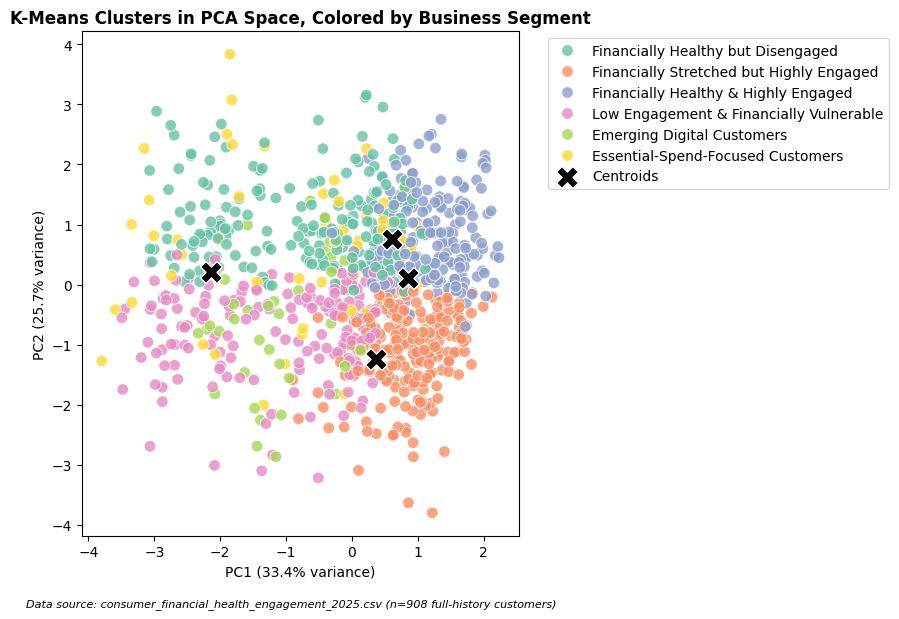

In [17]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(Xs)
var_exp = pca.explained_variance_ratio_

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Segment"] = cust_cluster["segment_label"]

plt.figure(figsize=(9, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Segment", palette="Set2", data=df_pca, alpha=0.8, s=70)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=250, c="black", edgecolor="white", label="Centroids")
plt.title("K-Means Clusters in PCA Space, Colored by Business Segment", fontweight="bold")
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.figtext(0.01, -0.02, "Data source: consumer_financial_health_engagement_2025.csv (n=908 full-history customers)", fontsize=8, style="italic")
plt.tight_layout()
plt.show()

Từ đồ thị PCA, ta rút ra được như sau:
+ Vùng trên-trái (PC2 cao, PC1 âm): Financially Healthy but Disengaged — nhóm này đứng cách xa centroid, phân tán rộng, cho thấy họ không đồng nhất về hành vi.
+ Vùng giữa-phải (PC1 dương): Financially Healthy & Highly Engaged — tập trung nhất, centroid rõ ràng nhất.
+ Vùng dưới-giữa (PC1 gần 0, PC2 âm): Financially Stretched but Highly Engaged — bám gần nhau nhưng trải dài theo PC2, cho thấy mức độ căng thẳng tài chính khác nhau đáng kể trong cùng nhóm.
+ Emerging Digital Customers (vàng) và Essential-Spend-Focused (cam nhạt) nằm rải rác ở rìa — xác nhận đây là overlay heuristic bổ sung chứ không phải cụm thuần K-Means.

Từ PCA, ta có những kết luận như sau:
- Emerging Digital Customers nằm ở "Hành tinh" riêng biệt: Nhóm này nằm tách biệt hoàn toàn ở vùng rìa không gian.

- Financially Healthy but Disengaged có độ phân tán rộng nhất Các điểm dữ liệu trải rộng từ trên xuống dưới thay vì co cụm. Nhóm này không đồng nhất do chứa nhiều lý do bỏ app khác nhau, vì vậy ngân hàng không thể áp dụng chung một thông điệp chăm sóc.

- Ranh giới mong manh giữa Financially Healthy và Financially Stretched: Hai nhóm này nằm áp sát nhau trên trục hành vi chính. Khoảng cách ngắn cho thấy chỉ cần một cú sốc tài chính đột ngột là khách hàng thuộc nhóm Healthy sẽ rớt xuống nhóm Stretched, đây là tín hiệu để hệ thống thiết lập cảnh báo sớm.

## 10.1 Phân tích nhóm khách hàng có lịch sử ngắn (91 KH ban đầu)

In [18]:
# 91 KH có < 12 tháng dữ liệu KHÔNG được dùng để fit KMeans/scaler ở mục 5-6
# (vì trung bình 9 biến của 1-2 tháng dữ liệu không ổn định, có thể làm méo centroid của cả mô hình)
# Ở đây ta chỉ TÍNH LẠI feature cho nhóm này rồi PREDICT bằng model đã fit sẵn, không fit lại từ đầu
cust_cluster_short = df_short.groupby("consumer_id")[cluster_cols].mean().reset_index()
cust_cluster_short[cluster_cols] = cust_cluster_short[cluster_cols].replace([np.inf, -np.inf], np.nan)

# fillna bằng median CỦA CHÍNH NHÓM SHORT (không dùng median của nhóm 908 KH)
# vì đây là 2 nhóm khách hàng có đặc điểm khác nhau (KH mới vs KH lâu năm), median mỗi nhóm phản ánh đúng nhóm đó
cust_cluster_short[cluster_cols] = cust_cluster_short[cluster_cols].fillna(
    cust_cluster_short[cluster_cols].median()
)

# Gộp thêm engagement_segment gốc để phục vụ gán nhãn segment_label ở dưới
cust_cluster_short = cust_cluster_short.merge(
    df_short.groupby("consumer_id")["engagement_segment"].first().reset_index(),
    on="consumer_id", how="left",
)

# QUAN TRỌNG: dùng lại đúng "bounds" (biên IQR) đã tính từ 908 KH full-history ở mục 5,
# KHÔNG tính IQR mới cho 91 KH này — nếu tính riêng sẽ tạo ra 2 thước đo khác nhau,
# khiến việc predict() sau đó không còn nằm trên cùng "thang đo" với model đã huấn luyện (data leakage kiểu ngược)
X_short_capped = cust_cluster_short[cluster_cols].copy()
for col in cluster_cols:
    lower, upper = bounds[col]
    X_short_capped[col] = X_short_capped[col].clip(lower=lower, upper=upper)

# scaler.transform (KHÔNG phải fit_transform): dùng lại đúng median/IQR đã học từ 908 KH
Xs_short = scaler.transform(X_short_capped)

# kmeans.predict (KHÔNG phải fit_predict): gán 91 KH vào cụm gần nhất trong 3 cụm đã có sẵn,
# không tạo cụm mới cho riêng nhóm này
cust_cluster_short["ml_cluster"] = [f"Cluster_{c}" for c in kmeans.predict(Xs_short)]

# Áp dụng ĐÚNG hàm assign_segment đã dùng cho 908 KH (bao gồm cả overlay Essential/Emerging Digital)
# để đảm bảo 91 KH này được gán nhãn theo cùng 1 tiêu chí, không bị lệch chuẩn so với nhóm còn lại
cust_cluster_short["health_band"] = pd.cut(
    cust_cluster_short["financial_health_score"], bins=health_band_edges, labels=HEALTH_LABELS
)
cust_cluster_short["engagement_level"] = cust_cluster_short["engagement_segment"].map({
    "Tương tác rất cao": "Engaged", "Tương tác cao": "Engaged",
    "Tương tác trung bình": "Disengaged", "Tương tác thấp": "Disengaged",
})
cust_cluster_short["segment_label"] = cust_cluster_short.apply(assign_segment, axis=1)

print(f"Đã tạo cust_cluster_short với {len(cust_cluster_short)} KH.")
print(cust_cluster_short["segment_label"].value_counts())

Đã tạo cust_cluster_short với 91 KH.
segment_label
Emerging Digital Customers                 86
Essential-Spend-Focused Customers           2
Low Engagement & Financially Vulnerable     2
Financially Healthy but Disengaged          1
Name: count, dtype: int64


In [19]:
cust_cluster_full = pd.concat(
    [cust_cluster[["consumer_id", "ml_cluster", "segment_label"]],
     cust_cluster_short[["consumer_id", "ml_cluster", "segment_label"]]],
    ignore_index=True,
)
assert cust_cluster_full["consumer_id"].nunique() == 999

reach_summary = (
    cust_cluster_full["segment_label"].value_counts()
    .rename_axis("segment_label").reset_index(name="n_customers")
)
reach_summary["pct_of_total"] = (reach_summary["n_customers"] / 999 * 100).round(1)
print("REACH CUỐI CÙNG")
print(reach_summary.sort_values("n_customers", ascending=False))


REACH CUỐI CÙNG
                              segment_label  n_customers  pct_of_total
0  Financially Stretched but Highly Engaged          232          23.2
1      Financially Healthy & Highly Engaged          208          20.8
2        Financially Healthy but Disengaged          200          20.0
3   Low Engagement & Financially Vulnerable          177          17.7
4                Emerging Digital Customers          126          12.6
5         Essential-Spend-Focused Customers           56           5.6


### 10.2. Profile chính thức cho toàn bộ 999 KH (908 full-history + 91 short-history)


In [20]:
full_features = pd.concat(
    [cust_cluster[["consumer_id"] + feature_cols],
     cust_cluster_short[["consumer_id"] + feature_cols]],
    ignore_index=True,
).merge(cust_cluster_full[["consumer_id", "segment_label"]], on="consumer_id")

profile_segment_999 = full_features.groupby("segment_label")[feature_cols].mean().round(3)
sizes_999 = full_features["segment_label"].value_counts()
profile_segment_999["n_customers"] = sizes_999
profile_segment_999["pct_customers"] = (sizes_999 / 999 * 100).round(1)

print("PROFILE CHÍNH THỨC THEO SEGMENT_LABEL (999 KH)")
display(profile_segment_999.sort_values("n_customers", ascending=False))

PROFILE CHÍNH THỨC THEO SEGMENT_LABEL (999 KH)


,financial_health_score,engagement_score,essential_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,category_diversity,transaction_recency_days,spending_volatility,n_customers,pct_customers
segment_label,,,,,,,,,,,
Financially Stretched but Highly Engaged,62.933,80.582,0.471,0.222,0.790,0.222,13.957,0.009,1.732,232,23.2
Financially Healthy & Highly Engaged,69.867,80.418,0.471,0.219,0.567,0.148,13.954,0.006,1.615,208,20.8
Financially Healthy but Disengaged,69.714,75.389,0.493,0.185,0.606,0.161,13.532,0.203,1.471,200,20.0
Low Engagement & Financially Vulnerable,62.841,75.117,0.483,0.187,0.834,0.234,13.444,0.188,1.492,177,17.7
Emerging Digital Customers,65.240,58.781,0.232,0.554,0.666,0.188,7.619,8.817,0.913,126,12.6
Essential-Spend-Focused Customers,68.175,73.643,0.583,0.173,0.681,0.192,13.168,1.019,1.386,56,5.6


In [21]:
cust_profile_short = pd.concat(
    [df_short.groupby("consumer_id")[cat_cols].first(),
     df_short.groupby("consumer_id")[num_cols].mean()],
    axis=1,
).reset_index()

cust_profile_full = pd.concat([cust_profile, cust_profile_short], ignore_index=True)
assert cust_profile_full["consumer_id"].nunique() == 999

all_features_merged = full_features.merge(cust_profile_full, on='consumer_id', how='left')

# Exclude non-numeric and identifier columns for median calculation
numeric_cols_for_median = all_features_merged.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['consumer_id', 'age'] # age is already covered by demo_age mean/median
numeric_cols_for_median = [col for col in numeric_cols_for_median if col not in exclude_cols]

median_profile = all_features_merged.groupby('segment_label')[numeric_cols_for_median].median().round(1)

print("=== BẢNG TRUNG VỊ CÁC CHỈ SỐ THEO PHÂN KHÚC (999 KH) ===")
display(median_profile.sort_values(by='financial_health_score', ascending=False))

=== BẢNG TRUNG VỊ CÁC CHỈ SỐ THEO PHÂN KHÚC (999 KH) ===


,financial_health_score,engagement_score,essential_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,category_diversity,transaction_recency_days,spending_volatility,monthly_income_vnd,credit_limit_vnd,average_transaction_value_vnd,transaction_count,active_transaction_days
segment_label,,,,,,,,,,,,,,
Financially Healthy & Highly Engaged,69.3,80.1,0.5,0.2,0.6,0.1,14.0,0.0,1.6,675281250.0,2.663200e+09,1610339.2,243.0,30.3
Financially Healthy but Disengaged,68.9,76.0,0.5,0.2,0.6,0.2,13.7,0.1,1.5,310417916.7,1.116000e+09,1690494.4,121.9,29.1
Essential-Spend-Focused Customers,68.3,76.6,0.6,0.2,0.7,0.2,13.6,0.0,1.4,263855000.0,9.846000e+08,1501271.8,121.9,29.3
Emerging Digital Customers,65.0,54.2,0.2,0.6,0.7,0.2,6.0,6.0,0.8,200095000.0,7.488000e+08,12892597.2,11.0,2.0
Low Engagement & Financially Vulnerable,63.8,76.3,0.5,0.2,0.8,0.2,13.6,0.1,1.5,213005000.0,7.544000e+08,1701215.6,121.9,29.0
Financially Stretched but Highly Engaged,63.4,80.2,0.5,0.2,0.8,0.2,14.0,0.0,1.7,491587916.7,1.749700e+09,1598667.0,243.2,30.3


### 10.3. Demographic profile cho 91 KH lịch sử ngắn


In [22]:
cust_profile_short = pd.concat(
    [df_short.groupby("consumer_id")[cat_cols].first(),
     df_short.groupby("consumer_id")[num_cols].mean()],
    axis=1,
).reset_index()

cust_profile_full = pd.concat([cust_profile, cust_profile_short], ignore_index=True)
assert cust_profile_full["consumer_id"].nunique() == 999


### 10.4. Ghép Demographics với segment_label để so sánh persona theo từng phân khúc


In [23]:
segment_demo = cust_cluster_full[["consumer_id", "segment_label"]].merge(
    cust_profile_full, on="consumer_id", how="left"
)

demo_age = segment_demo.groupby("segment_label")["age"].agg(["mean", "median"]).round(1)
demo_money = segment_demo.groupby("segment_label")[
    ["monthly_income_vnd", "average_transaction_value_vnd"]
].mean().round(0)
demo_gender_pct = (
    segment_demo.groupby(["segment_label", "gender"]).size()
    .groupby(level=0).apply(lambda x: (x / x.sum() * 100).round(1))
)
demo_top_occupation = segment_demo.groupby("segment_label")["occupation"] \
    .agg(lambda x: x.value_counts().idxmax())
demo_top_province = segment_demo.groupby("segment_label")["province_city"] \
    .agg(lambda x: x.value_counts().idxmax())

print(" TUỔI (mean/median) THEO SEGMENT "); display(demo_age)
print("\n THU NHẬP & GIÁ TRỊ GIAO DỊCH TRUNG BÌNH THEO SEGMENT "); display(demo_money)
print("\n NGHỀ NGHIỆP PHỔ BIẾN NHẤT THEO SEGMENT "); display(demo_top_occupation)
print("\n TỈNH/THÀNH TẬP TRUNG NHẤT THEO SEGMENT "); display(demo_top_province)
print("\n PHÂN BỔ GIỚI TÍNH (%) THEO SEGMENT "); display(demo_gender_pct)

 TUỔI (mean/median) THEO SEGMENT 


,mean,median
segment_label,,
Emerging Digital Customers,52.8,56.0
Essential-Spend-Focused Customers,57.4,56.0
Financially Healthy & Highly Engaged,44.3,41.5
Financially Healthy but Disengaged,57.8,58.0
Financially Stretched but Highly Engaged,42.0,40.0
Low Engagement & Financially Vulnerable,54.3,54.0



 THU NHẬP & GIÁ TRỊ GIAO DỊCH TRUNG BÌNH THEO SEGMENT 


,monthly_income_vnd,average_transaction_value_vnd
segment_label,,
Emerging Digital Customers,227691706.0,11151963.0
Essential-Spend-Focused Customers,305439048.0,1602989.0
Financially Healthy & Highly Engaged,746067764.0,1792671.0
Financially Healthy but Disengaged,338840467.0,1827021.0
Financially Stretched but Highly Engaged,521503718.0,1739678.0
Low Engagement & Financially Vulnerable,243990071.0,1926693.0



 NGHỀ NGHIỆP PHỔ BIẾN NHẤT THEO SEGMENT 


,occupation
segment_label,
Emerging Digital Customers,Chuyên viên nhân sự
Essential-Spend-Focused Customers,Nhà khoa học phát triển sản phẩm
Financially Healthy & Highly Engaged,Bác sĩ chuyên khoa bàn chân
Financially Healthy but Disengaged,Nhà khoa học thính học
Financially Stretched but Highly Engaged,Chuyên viên trắc địa
Low Engagement & Financially Vulnerable,Nhà văn khoa học



 TỈNH/THÀNH TẬP TRUNG NHẤT THEO SEGMENT 


,province_city
segment_label,
Emerging Digital Customers,Thành phố Hồ Chí Minh
Essential-Spend-Focused Customers,Thành phố Hồ Chí Minh
Financially Healthy & Highly Engaged,Thành phố Hồ Chí Minh
Financially Healthy but Disengaged,Thành phố Hồ Chí Minh
Financially Stretched but Highly Engaged,Thành phố Hồ Chí Minh
Low Engagement & Financially Vulnerable,Thành phố Hồ Chí Minh



 PHÂN BỔ GIỚI TÍNH (%) THEO SEGMENT 


segment_label                             segment_label                             gender
Emerging Digital Customers                Emerging Digital Customers                Nam       47.6
                                                                                    Nữ        52.4
Essential-Spend-Focused Customers         Essential-Spend-Focused Customers         Nam       37.5
                                                                                    Nữ        62.5
Financially Healthy & Highly Engaged      Financially Healthy & Highly Engaged      Nam       45.2
                                                                                    Nữ        54.8
Financially Healthy but Disengaged        Financially Healthy but Disengaged        Nam       53.0
                                                                                    Nữ        47.0
Financially Stretched but Highly Engaged  Financially Stretched but Highly Engaged  Nam       47.4
                                                                                    Nữ        52.6
Low Engagement & Financially Vulnerable   Low Engagement & Financially Vulnerable   Nam       58.2
                                                                                    Nữ        41.8
dtype: float64

### 11. Đào sâu Insight Kinh tế & Thực tiễn vận hành (What - Why - So What)

Dưới đây là bảng tổng hợp các phân tích chiến lược dựa trên kết quả phân khúc thực tế của 999 khách hàng, phục vụ trực tiếp cho việc thiết kế **Action Plan phi trừng phạt** ở Task 5.

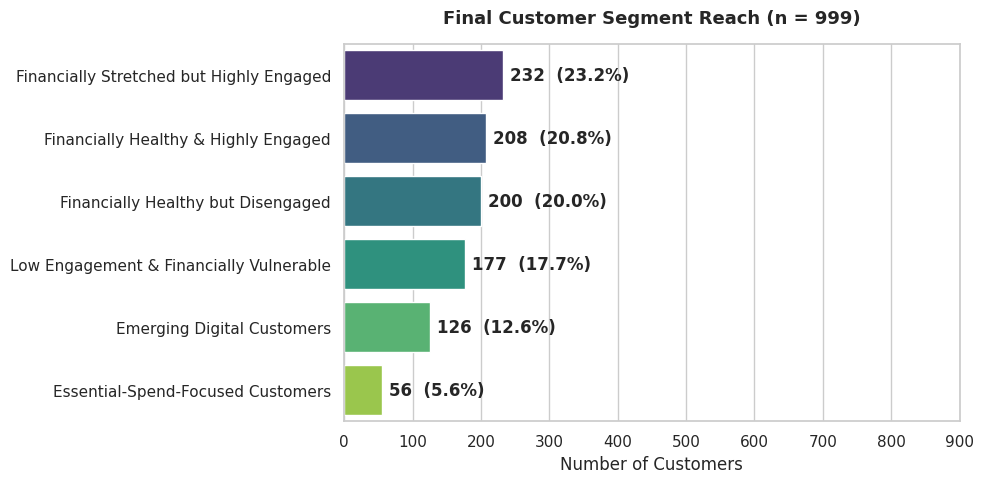

In [26]:
# Trực quan hóa tỷ lệ phân bổ phân khúc khách hàng cuối cùng để báo cáo ban giám đốc (C-level)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x="n_customers",
    y="segment_label",
    data=reach_summary,
    palette="viridis",
    hue="segment_label",
    legend=False
)

# Thêm số lượng và tỷ lệ phần trăm trực tiếp lên biểu đồ
for p in ax.patches:
    width = p.get_width()
    pct = (width / 999 * 100)
    ax.text(
        width + 10,
        p.get_y() + p.get_height() / 2,
        f"{int(width)}  ({pct:.1f}%)",
        ha="left",
        va="center",
        fontweight="bold"
    )

plt.title("Final Customer Segment Reach (n = 999)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Number of Customers")
plt.ylabel("")
plt.xlim(0, 900)
plt.tight_layout()
plt.show()

## 12. Hạn chế & Hướng phát triển

### 12.1 Hạn chế

**1. Lịch sử quan sát còn hạn chế**

91/999 khách hàng (9,1%) chỉ có 1–2 tháng dữ liệu, trong khi 908 khách hàng có đủ 12 tháng.

Nhóm short-history không được dùng để huấn luyện K-Means, nhưng segment được dự đoán cho họ có độ tin cậy thấp hơn vì profile hành vi chỉ dựa trên số tháng quan sát rất ít.

**2. Mức độ tách biệt giữa các cluster còn vừa phải**

Mô hình K-Means với K=4 tạo ra các cluster ổn định và tương đối dễ diễn giải, nhưng Silhouette Score chỉ khoảng 0,22.

Điều này cho thấy các nhóm khách hàng chưa tách biệt hoàn toàn và vẫn có sự chồng lấn về hành vi giữa các cluster.

**3. Một số feature có thông tin trùng lặp**

Một số biến trong model có tương quan cao và có thể cùng phản ánh một khía cạnh hành vi.

Ví dụ:

- `financial_health_score` liên quan mạnh với `spend_to_income_ratio` và `credit_utilization_ratio`.
- `engagement_score` liên quan mạnh với `category_diversity` và các biến engagement khác.

Do K-Means dựa trên khoảng cách, các feature tương quan có thể vô tình khiến một số dimension được model đặt trọng số lớn hơn.

**4. Kết quả phụ thuộc vào các business rule và threshold**

Business segmentation cuối cùng có sử dụng thêm các rule và threshold về financial health, engagement và hành vi chi tiêu.

Do đó, số lượng khách trong từng segment và tên segment có thể thay đổi nếu chọn threshold khác.

Các threshold này nên được hiểu là quy tắc phân tích phục vụ business, không phải định nghĩa cố định áp dụng cho mọi khách hàng.

**5. Aggregate theo năm có thể che mất biến động theo thời gian**

Các quan sát theo tháng được tổng hợp thành một profile duy nhất cho mỗi khách hàng.

Cách này giúp segmentation dễ diễn giải hơn, nhưng có thể làm mất thông tin về sự thay đổi trong năm, ví dụ khách hàng có financial health hoặc engagement tăng/giảm theo thời gian.

**6. Dataset là dữ liệu synthetic**

Dữ liệu về thu nhập, hạn mức tín dụng, số dư và các giá trị tài chính khác là dữ liệu giả lập.

Vì vậy các segment nên được hiểu là pattern phân tích trong dataset này và không nên áp dụng trực tiếp cho khách hàng thực tế nếu chưa được kiểm chứng thêm.

---

### 12.2 Hướng phát triển

**1. Đánh giá lại nhóm short-history**

Xem assignment của nhóm short-history là tạm thời và cập nhật lại segment khi có thêm lịch sử quan sát.

**2. Thử các bộ feature khác**

Kiểm tra các bộ feature rút gọn để giảm redundancy và đánh giá xem cấu trúc segment chính có còn ổn định khi loại bớt các biến tương quan cao hay không.

**3. So sánh với các thuật toán clustering khác**

Thử thêm các phương pháp như Gaussian Mixture Model (GMM) hoặc Hierarchical Clustering để kiểm tra xem các cấu trúc khách hàng tương tự có được tái hiện hay không.

**4. Kiểm tra độ nhạy của threshold**

Thử nhiều mức threshold khác nhau cho health, engagement và behavioral rules để đánh giá segment size và profile thay đổi như thế nào.

**5. Phát triển segmentation theo thời gian**

Mở rộng từ segmentation tĩnh sang segmentation theo tháng/longitudinal để theo dõi:

- khách hàng chuyển segment,
- thay đổi financial health,
- thay đổi engagement,
- các behavioral pattern mới xuất hiện.

**6. Kiểm chứng trên dữ liệu thực tế**

Trước khi áp dụng thực tế, cần hiệu chỉnh và kiểm chứng lại framework trên dữ liệu khách hàng thật, bao gồm kiểm tra độ ổn định, fairness và hiệu quả kinh doanh.

---

### Lưu ý diễn giải

`financial_health_score` chỉ được sử dụng như một chỉ báo về tình trạng tài chính.

Framework segmentation này nhằm phục vụ việc hiểu khách hàng, tăng engagement và thiết kế các biện pháp hỗ trợ, không được dùng để phê duyệt/từ chối tín dụng, giảm hạn mức hoặc khóa tài khoản.

In [25]:
# =========================================================
# EXPORT FINAL DELIVERABLES FOR TASK 4 / TASK 5
# =========================================================

# ---------------------------------------------------------
# A. PREPROCESSED CUSTOMER-LEVEL DATASET
# ---------------------------------------------------------

# Số tháng quan sát của mỗi customer
observed_months = (
    df.groupby("consumer_id")["analysis_month"]
      .nunique()
      .rename("observed_months")
      .reset_index()
)

# Gắn history status
observed_months["history_status"] = np.where(
    observed_months["observed_months"] == 12,
    "Full History",
    "Short History"
)

# Ghép 9 features + cluster + segment
preprocessed_export = pd.concat(
    [
        cust_cluster[["consumer_id"] + feature_cols],
        cust_cluster_short[["consumer_id"] + feature_cols]
    ],
    ignore_index=True
)

preprocessed_export = (
    preprocessed_export
    .merge(observed_months, on="consumer_id", how="left")
    .merge(
        cust_cluster_full[
            ["consumer_id", "ml_cluster", "segment_label"]
        ],
        on="consumer_id",
        how="left"
    )
)

# Đánh dấu độ tin cậy assignment
preprocessed_export["assignment_status"] = np.where(
    preprocessed_export["history_status"] == "Full History",
    "Model-based",
    "Provisional"
)

preprocessed_export.to_csv(
    "customer_segmentation_preprocessed.csv",
    index=False
)

# ---------------------------------------------------------
# B. CUSTOMER → SEGMENT MAPPING
# ---------------------------------------------------------

customer_mapping = (
    cust_cluster_full
    .merge(observed_months, on="consumer_id", how="left")
)

customer_mapping["assignment_status"] = np.where(
    customer_mapping["history_status"] == "Full History",
    "Model-based",
    "Provisional"
)

customer_mapping.to_csv(
    "customer_segment_mapping.csv",
    index=False
)

# ---------------------------------------------------------
# C. SEGMENT PROFILE SUMMARY
# ---------------------------------------------------------

segment_profile_export = (
    profile_segment_999
    .reset_index()
    .sort_values("n_customers", ascending=False)
)

segment_profile_export.to_csv(
    "segment_profile_summary.csv",
    index=False
)

# ---------------------------------------------------------
# D. DEMOGRAPHIC PROFILE
# ---------------------------------------------------------

segment_demo.to_csv(
    "segment_demographic_detail.csv",
    index=False
)

print("Export completed:")
print("1. customer_segmentation_preprocessed.csv")
print("2. customer_segment_mapping.csv")
print("3. segment_profile_summary.csv")
print("4. segment_demographic_detail.csv")

Export completed:
1. customer_segmentation_preprocessed.csv
2. customer_segment_mapping.csv
3. segment_profile_summary.csv
4. segment_demographic_detail.csv
